In [1]:
import sys
import os
sys.path.append(os.path.abspath('/bigdata/saleslab/psadh003/tng50/dwarf_formation'))
import pandas as pd 
import matplotlib.pyplot as plt
import IPython
import numpy as np 
from dwarf_plotting import plot_lg_virgo, plot_lg_vd, plot_lg_virgo_some
# from Pradyumna_plot import plot_tng_subhalos #This is to plot the subhalos from TNG
import matplotlib
import illustris_python as il
from errani_plus_tng_subhalo import Subhalo
from populating_stars import *
from subhalo_profiles import NFWProfile
import ast
from colossus.cosmology import cosmology
from colossus.halo import concentration
from plot_sachi import plot_sachi
from scipy.optimize import fsolve
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.collections as mc
from matplotlib.legend_handler import HandlerTuple
from testing_errani import get_rmxbyrmx0, get_vmxbyvmx0, get_mxbymx0, get_LbyL0, l10rbyrmx0_1by4_spl,l10rbyrmx0_1by2_spl, l10rbyrmx0_1by8_spl, l10rbyrmx0_1by16_spl, l10vbyvmx0_1by2_spl, l10vbyvmx0_1by4_spl, l10vbyvmx0_1by8_spl, l10vbyvmx0_1by16_spl, l10rbyrmx0_1by66_spl, l10rbyrmx0_1by250_spl, l10rbyrmx0_1by1000_spl, l10vbyvmx0_1by66_spl, l10vbyvmx0_1by250_spl, l10vbyvmx0_1by1000_spl
import matplotlib.ticker as ticker
import re

cosmology.setCosmology('planck18')


ages_df = pd.read_csv('/bigdata/saleslab/psadh003/tng50-dark-analysis/ages_tng.csv', comment = '#')

all_snaps = np.array(ages_df['snapshot'])
all_redshifts = np.array(ages_df['redshift'])
all_ages = np.array(ages_df['age(Gyr)'])

/bigdata/saleslab/psadh003/tng50/dwarf_formation/dwarf_plotting.py:55: RuntimeWarning: invalid value encountered in sqrt
  rh_proj *= np.sqrt(1.-ell)


A new version of galpy (1.11.0) is available, please upgrade using pip/conda/... to get the latest features and bug fixes!


### Plot parameters

In [2]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size' : 14}

plt.figure()
plt.close()
matplotlib.rc('font', **font)
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['lines.linewidth'] = 3
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (6, 6)

label_font = 20

### Some utility functions

In [3]:
def convert_to_float(value):
    try:
        if isinstance(value, float) or isinstance(value, int):
            return value

        if value == '[inf, inf, inf]' or value == '[inf inf inf]':
            return np.array([np.inf, np.inf, np.inf])

        if value == '[inf]':
            return np.inf
        
        if value == 'inf':
            return np.inf
        

        if value == '[-inf]':
            return -np.inf

        

        blah = ast.literal_eval(value)
        if isinstance(blah, list):
            if len(blah) == 1:
                blah2 = float(blah[0])   
            elif len(blah) == 3:
                blah2 = np.array([float(blah[0]), float(blah[1]), float(blah[2])])
        else:
            blah2 = float(blah)        
        return blah2
    except Exception as e:
        try:
            value_fixed = re.sub(r'(?<=\d)\s+(?=-?\d)', ', ', value)  # Handle spaces between numbers
            value_fixed = re.sub(r'(?<=\d)\s+(?=\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=-\d)', ', ', value_fixed)
            value_fixed = re.sub(r'(?<=\.)\s+(?=\d)', ', ', value_fixed)
            # Now use ast.literal_eval
            # print(value_fixed)
            result = ast.literal_eval(value_fixed)
            return result
        except Exception as e:
            print(value)
            return value
        
def get_med_values(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.median(np.reshape(arr, (cuts, -1)), axis = 0)

def get_quantiles(arr, cuts):
    '''
    This is going to take one big array of length cuts*whatever, breaks it into cuts parts and returns medians of the corresponding elements
    '''
    return np.quantile(np.reshape(arr, (cuts, -1)), axis = 0, q = [0.05, 0.95])

### Paths for files that we have

In [4]:
basePath = '/rhome/psadh003/bigdata/L35n2160TNG_fixed/output'
outpath  = '/rhome/psadh003/bigdata/tng50/output_files/'
plotpath = '/bigdata/saleslab/psadh003/tng50/output_plots/'
misc_path = '/bigdata/saleslab/psadh003/misc_files/'
ferrarese_data_path = '/bigdata/saleslab/psadh003/misc_files/Ferrarese_virgo_smf.csv'
venhola_data_path = '/bigdata/saleslab/psadh003/misc_files/Venhola_fornax_smf.csv'

### Finding the best fit NFW profiles for dark matter in TNG50

In [5]:
h = 0.6774 # Hubble constant / 100

def nfw_mass(r, lrhos, lrs):
    '''
    This gives the NFW mass profile at a given radius r, we do not care much about the units here, since we normalize the density profile later
    '''
    rhos = 10**lrhos
    rs = 10**lrs
    mass =  4 * np.pi * rhos * rs ** 3 * (np.log(1 + (r/rs))  -  r / (r + rs))
    return mass


def nfw_dens(r, rhos, rs):
    '''
    This gives the NFW density profile at a given radius r, we do not care much about the units here
    since we normalize the density profile later
    '''
    dens = rhos / ((r/rs) * (1 + (r / rs)) ** 2)
    return dens



# Following calculations are for the best-fit NFW profiles


# ================== For the FoF-0 ==================

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 0)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_0 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_0 = this_fof['Group_R_Crit200'] / h
v200_0 = np.sqrt(G * m200_0 / r200_0)
central_sfid_99_0 = central_sfid_99


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    # result = np.array([np.log10(nfw_mass(rh, lrhos, lrs)) - np.log10(float(mdm_rh)), np.log10(nfw_mass(r_vmax, lrhos, lrs)) - np.log10(float(mdm_vmax)), 
    #                    np.log10(nfw_mass(2 * rh, lrhos, lrs)) - np.log10(float(mdm_2rh))]).ravel()
    # print(f"Params: {params}, Result: {result}")
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_0 = 10**lrhos
rs_0 = 10**lrs

# ======================= For the FoF-1 =======================

this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 1)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_1 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_1 = this_fof['Group_R_Crit200'] / h
v200_1 = np.sqrt(G * m200_1 / r200_1)
central_sfid_99_1 = central_sfid_99


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    # result = np.array([np.log10(nfw_mass(rh, lrhos, lrs)) - np.log10(float(mdm_rh)), np.log10(nfw_mass(r_vmax, lrhos, lrs)) - np.log10(float(mdm_vmax)), 
    #                    np.log10(nfw_mass(2 * rh, lrhos, lrs)) - np.log10(float(mdm_2rh))]).ravel()
    # print(f"Params: {params}, Result: {result}")
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_1 = 10**lrhos
rs_1 = 10**lrs


# ============== For the FoF-2 =================


this_fof = il.groupcat.loadSingle(basePath, 99, haloID = 2)
central_sfid_99 = this_fof['GroupFirstSub']
cen = il.groupcat.loadSingle(basePath, 99, subhaloID = central_sfid_99)
m200_2 = this_fof['Group_M_Crit200'] * 1e10 / h
r200_2 = this_fof['Group_R_Crit200'] / h
v200_2 = np.sqrt(G * m200_2 / r200_2)
central_sfid_99_2 = central_sfid_99


# Following are the radii where we will be fitting the best-fit NFW profiles to the data from the Group catalog
r1 = 2 * cen['SubhaloHalfmassRadType'][4] /h
m1 = cen['SubhaloMassInRadType'][1] * 1e10/h

r2 = cen['SubhaloHalfmassRadType'][1]/h
m2 = cen['SubhaloMassType'][1] * 1e10/h / 2.

def simul_func(params):
    lrhos, lrs = params
    result = np.array([np.log10(nfw_mass(r1, lrhos, lrs)) - np.log10(float(m1)), np.log10(nfw_mass(r2, lrhos, lrs)) - np.log10(float(m2))]).ravel()
    return result

input_values = [2, 2.7]
lrhos, lrs = fsolve(simul_func, input_values)

# Following are the best fit NFW parameters
rhos_2 = 10**lrhos
rs_2 = 10**lrs


# We now have the best-fit NFW parameters for the FoF-0, FoF-1 and FoF-2 halos, we can now use these to get the density profiles for the subhalos

### Functions that best-fit an Einasto profile to input data

In [6]:
from scipy.optimize import curve_fit

def einasto_density(lr, lrhos, lrs, lalpha):
    '''
    This gives the Einasto density profile at a given radius r, we do not care much about the units here
    since we normalize the density profile later
    '''
    r = 10**lr
    rhos = 10**lrhos
    rs = lrs
    alpha = lalpha
    dens = rhos * np.exp((-2/alpha) * ((r/rs) ** alpha - 1))
    return np.log10(dens)


def fit_einasto(r, density):
    """
    Fit the Einasto profile to the given density data.

    Parameters
    ----------
    r : array-like
        Radial distances.
    density : array-like
        Observed density values.

    Returns
    -------
    params : tuple
        Best-fit parameters (rho_s, r_s, alpha).
    cov : 2D array
        Covariance matrix of the fit.
    """
    # Initial guesses for parameters (can be adjusted based on data)
    rho_s_guess = density.max()
    r_s_guess = r[np.argmax(density)]
    alpha_guess = 1.5
    
    print(rho_s_guess, r_s_guess, alpha_guess)
    # p0 = [np.log10(rho_s_guess), np.log10(r_s_guess), alpha_guess]
    p0 = [np.log10(rho_s_guess), 0.1, alpha_guess]
    
    # Perform the curve fitting
    try:
        params, cov = curve_fit(einasto_density, np.log10(r), np.log10(density), p0=p0, bounds=((-1, 0.1, 0.1), (10, 10**-0.23, 2)))
        return params, cov
    except RuntimeError as e:
        print("Fit did not converge:", e)
        return None, None


In [7]:
# This would be the information for Type-1 subhalos
filepath = '/bigdata/saleslab/psadh003/tng50dark/tng_files/'

df0 = pd.read_csv(filepath +  'hydrofofno_' + str(0) + '.csv', delimiter = ',', low_memory=False)
df1 = pd.read_csv(filepath +  'hydrofofno_' + str(1) + '.csv', delimiter = ',', low_memory=False)
df2 = pd.read_csv(filepath +  'hydrofofno_' + str(2) + '.csv', delimiter = ',', low_memory=False)
df = pd.concat([df0, df1, df2], ignore_index = True)
t1_vmax_if_ar = df['vmax_if_ar'].values
t1_vpeak_ar = df['vpeak'].values
t1_snap_if_ar = np.array(df['snap_if_ar'].values, dtype = int)
t1_sfid_if_ar = np.array(df['sfid_if_ar'].values, dtype = int)
t1_fof = df['fof'].values


In [8]:
# Let us combine all the three set of files which have the data for the distance of Type-2 subhalos
df0 = pd.read_csv(filepath + 'hydrofofno_' + str(0) + '_t2.csv', comment = '#')
# df0['fof'] = 0
df1 = pd.read_csv(filepath + 'hydrofofno_' + str(1) + '_t2.csv', comment = '#')
df2 = pd.read_csv(filepath + 'hydrofofno_' + str(2) + '_t2.csv', comment = '#')
df = pd.concat([df0, df1, df2], ignore_index = True)
t2_snap_if_ar = np.array(df['snap_if_ar'], dtype=int) # This is the infall snap of the subhalo
t2_sfid_if_ar = np.array(df['sfid_if_ar'], dtype=int) # This is the infall sfid of the subhalo
t2_snap_merger_ar = np.array(df['snap_merger_ar'], dtype=int) # This is the merger snap of the subhalo
t2_sfid_merger_ar = np.array(df['sfid_merger_ar'], dtype = int) # This is the merger sfid of the subhalo
t2_posx_ar = np.array(df['posx_ar']) # This is the x position of the subhalo
t2_posy_ar = np.array(df['posy_ar']) # This is the y position of the subhalo
t2_posz_ar = np.array(df['posz_ar']) # This is the z position of the subhalo
t2_dist_ar = np.sqrt(t2_posx_ar ** 2 + t2_posy_ar ** 2 + t2_posz_ar ** 2) # This is the distance of the subhalo from the center of the FoF
t2_vmax_if_ar = np.array(df['vmax_if_ar']) # This is the vmax of the subhalo
t2_vpeak_ar = np.array(df['vpeak']) # This is the vpeak of the subhalo
t2_fof = np.array(df['fof']) # This is the fof of the subhalo
t2_sfid_into_ar = np.array(df['sfid_into_ar'], dtype = int) # This is the sfid of the subhalo into which the subhalo has fallen into

In [9]:
# suffix = '_newpl' # This is the attempt where we have used the new power law
# suffix = '_Vpeak_newall' # This is the attempt where we have used the new power law
# suffix = '_vpeak_bestfits' # This is the attempt where we have used the new power law
suffix = '_interpolation' # This is the attempt where we have used the new power law
filepath = '/bigdata/saleslab/psadh003/tng50dark/tng_files/'

df0 = pd.read_csv(filepath + 'fof0_surviving_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df1 = pd.read_csv(filepath + 'fof1_surviving_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df2 = pd.read_csv(filepath + 'fof2_surviving_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)

a4_t1_df = pd.concat([df0, df1, df2], ignore_index = True)  # This is the dataframe for the surviving subhalos

a4_t1_df = a4_t1_df.applymap(convert_to_float)
a4_t1_dist_f_ar = a4_t1_df['dist_f_ar'].values
a4_t1_hof_flag = a4_t1_df['hof_flag'].values
a4_t1_fof = a4_t1_df['fof'].values

a4_t1_vpeak_ar = a4_t1_df['vpeak_ar'].values

a4_t1_rrel = np.zeros(len(a4_t1_fof))
a4_t1_rrel[a4_t1_fof == 0] = a4_t1_dist_f_ar[a4_t1_fof == 0] / r200_0
a4_t1_rrel[a4_t1_fof == 1] = a4_t1_dist_f_ar[a4_t1_fof == 1] / r200_1
a4_t1_rrel[a4_t1_fof == 2] = a4_t1_dist_f_ar[a4_t1_fof == 2] / r200_2



#=============================
# This is where we apply the conditions
#=============================

a4_t1_df = a4_t1_df[(a4_t1_dist_f_ar > 50) & (a4_t1_rrel < 1) & (a4_t1_vpeak_ar > 12)]
a4_t1_dist_f_ar = a4_t1_df['dist_f_ar'].values

#==============================
a4_t1_mstar_max_ar = a4_t1_df['mstar_max_ar'].values
a4_t1_rh_max_ar = a4_t1_df['rh_max_ar'].values
a4_t1_rh_f_ar = a4_t1_df['rh_f_ar'].values
a4_t1_rh_f_pl_ar = a4_t1_df['rh_f_pl_ar'].values
a4_t1_rh_f_co_ar = a4_t1_df['rh_f_co_ar'].values
a4_t1_rh_max_pl_ar = a4_t1_df['rh_max_pl_ar'].values
a4_t1_rh_max_co_ar = a4_t1_df['rh_max_co_ar'].values
a4_t1_mstar_f_ar_tng = a4_t1_df['mstar_f_ar_tng'].values
a4_t1_mmx_f_ar_tng = a4_t1_df['mmx_f_ar_tng'].values
a4_t1_rmx_f_ar_tng = a4_t1_df['rmx_f_ar_tng'].values
a4_t1_rh_f_ar_tng = a4_t1_df['rh_f_ar_tng'].values
a4_t1_rmx_if_ar = a4_t1_df['rmx_if_ar'].values
a4_t1_mstar_max_pl_ar = a4_t1_df['mstar_max_pl_ar'].values
a4_t1_mstar_max_co_ar = a4_t1_df['mstar_max_co_ar'].values
a4_t1_mstar_f_ar = a4_t1_df['mstar_f_ar'].values
a4_t1_mstar_f_pl_ar = a4_t1_df['mstar_f_pl_ar'].values
a4_t1_mstar_f_co_ar = a4_t1_df['mstar_f_co_ar'].values
a4_t1_mstar_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_mstar_co_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_co_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_max_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_rh_max_co_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_mstar_if_ar = a4_t1_df['mstar_if_ar'].values
a4_t1_snap_if_ar = a4_t1_df['snap_if_ar'].values
a4_t1_fof = a4_t1_df['fof'].values
a4_t1_sfid_if_ar = a4_t1_df['sfid_if_ar'].values
a4_t1_vmx_if_ar  = a4_t1_df['vmx_if_ar'].values
a4_t1_rperi_ar = a4_t1_df['rperi_ar'].values
a4_t1_rapo_ar = a4_t1_df['rapo_ar'].values
a4_t1_mmx_if_ar = a4_t1_df['mmx_if_ar'].values
a4_t1_mmx_f_ar = a4_t1_df['mmx_f_ar'].values
a4_t1_rmx_f_ar = a4_t1_df['rmx_f_ar'].values
a4_t1_vmax_if_ar = a4_t1_df['vmax_if_ar'].values
a4_t1_vpeak_ar = a4_t1_df['vpeak_ar'].values
a4_t1_torb = a4_t1_df['torb_ar'].values
a4_t1_hof_flag = a4_t1_df['hof_flag'].values


massive_ixs = np.where(a4_t1_mstar_max_ar > 1e11)[0]
res_ixs = np.where((a4_t1_mstar_max_ar > 5e6) & (a4_t1_mstar_max_ar < 1e11))[0]
unres_ixs = np.where(a4_t1_mstar_max_ar < 5e6)[0]

a4_t1_mstar_pl_all[res_ixs] = a4_t1_mstar_f_ar[res_ixs]
a4_t1_mstar_pl_all[unres_ixs] = a4_t1_mstar_f_pl_ar[unres_ixs]
a4_t1_mstar_pl_all[massive_ixs] = a4_t1_mstar_f_ar_tng[massive_ixs]

a4_t1_mstar_co_all[res_ixs] = a4_t1_mstar_f_ar[res_ixs]
a4_t1_mstar_co_all[unres_ixs] = a4_t1_mstar_f_co_ar[unres_ixs]
a4_t1_mstar_co_all[massive_ixs] = a4_t1_mstar_f_ar_tng[massive_ixs]

a4_t1_mstar_max_pl_all = np.zeros(len(a4_t1_dist_f_ar))
a4_t1_mstar_max_co_all = np.zeros(len(a4_t1_dist_f_ar))

a4_t1_mstar_max_pl_all[res_ixs] = a4_t1_mstar_max_ar[res_ixs]
a4_t1_mstar_max_pl_all[unres_ixs] = a4_t1_mstar_max_pl_ar[unres_ixs]
a4_t1_mstar_max_pl_all[massive_ixs] = a4_t1_mstar_max_ar[massive_ixs]

a4_t1_mstar_max_co_all[res_ixs] = a4_t1_mstar_max_ar[res_ixs]
a4_t1_mstar_max_co_all[unres_ixs] = a4_t1_mstar_max_co_ar[unres_ixs]
a4_t1_mstar_max_co_all[massive_ixs] = a4_t1_mstar_max_ar[massive_ixs]

a4_t1_rh_pl_all[res_ixs] = a4_t1_rh_f_ar[res_ixs]
a4_t1_rh_pl_all[unres_ixs] = a4_t1_rh_f_pl_ar[unres_ixs]
a4_t1_rh_pl_all[massive_ixs] = a4_t1_rh_f_ar_tng[massive_ixs]

a4_t1_rh_co_all[res_ixs] = a4_t1_rh_f_ar[res_ixs]
a4_t1_rh_co_all[unres_ixs] = a4_t1_rh_f_co_ar[unres_ixs]
a4_t1_rh_co_all[massive_ixs] = a4_t1_rh_f_ar_tng[massive_ixs]


a4_t1_rh_max_pl_all[res_ixs] = a4_t1_rh_max_ar[res_ixs]
a4_t1_rh_max_pl_all[unres_ixs] = a4_t1_rh_max_pl_ar[unres_ixs]
a4_t1_rh_max_pl_all[massive_ixs] = a4_t1_rh_max_ar[massive_ixs]

a4_t1_rh_max_co_all[res_ixs] = a4_t1_rh_max_ar[res_ixs]
a4_t1_rh_max_co_all[unres_ixs] = a4_t1_rh_max_co_ar[unres_ixs]
a4_t1_rh_max_co_all[massive_ixs] = a4_t1_rh_max_ar[massive_ixs]

a4_t1_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_pl_all/(np.pi * (a4_t1_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t1_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_co_all/(np.pi * (a4_t1_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2

a4_t1_pos_f_ar = np.stack(np.array(a4_t1_df['pos_f_ar'].values))
#Calculating the projected distances
a4_t1_xy_dist_f_ar = np.sqrt(a4_t1_pos_f_ar[:, 0] ** 2 + a4_t1_pos_f_ar[:, 1] ** 2)
a4_t1_xz_dist_f_ar = np.sqrt(a4_t1_pos_f_ar[:, 0] ** 2 + a4_t1_pos_f_ar[:, 2] ** 2)
a4_t1_yz_dist_f_ar = np.sqrt(a4_t1_pos_f_ar[:, 1] ** 2 + a4_t1_pos_f_ar[:, 2] ** 2)

/tmp/ipykernel_1895836/313403381.py:114: RuntimeWarning: invalid value encountered in log10
  a4_t1_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_pl_all/(np.pi * (a4_t1_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2

/tmp/ipykernel_1895836/313403381.py:115: RuntimeWarning: invalid value encountered in log10
  a4_t1_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t1_mstar_co_all/(np.pi * (a4_t1_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2



In [10]:
# This is the cell for Type-2s input
filepath = '/bigdata/saleslab/psadh003/tng50dark/tng_files/'
# suffix = '_newpl' # This is the attempt where we have used the new power law
# suffix = '_Vpeak_newall' # This is the attempt where we have used the new power law
# suffix = '_vpeak_bestfits' # This is the attempt where we have used the new power law
suffix = '_interpolation' # This is the attempt where we have used the new power law
df0 = pd.read_csv(filepath + 'fof0_merged_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df1 = pd.read_csv(filepath + 'fof1_merged_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)
df2 = pd.read_csv(filepath + 'fof2_merged_evolved_everything' + suffix + '.csv', delimiter= ',', low_memory=False)

a4_t2_df = pd.concat([df0, df1, df2], ignore_index = True)  # This is the dataframe for the merged subhalos


a4_t2_df = a4_t2_df.applymap(convert_to_float)

# ==============================
# This is where we apply the conditions
# ==============================
a4_t2_posx_ar = a4_t2_df['posx'].values
a4_t2_posy_ar = a4_t2_df['posy'].values
a4_t2_posz_ar = a4_t2_df['posz'].values
a4_t2_hof_flag = a4_t2_df['hof_flag'].values
a4_t2_desc_flag = a4_t2_df['desc_flag'].values
a4_t2_vpeak_ar = a4_t2_df['vpeak_ar'].values
a4_t2_desc_flag = a4_t2_desc_flag.astype(bool)

a4_t2_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posy_ar ** 2 + a4_t2_posz_ar ** 2)

print(f'Fraction that pass desc_flag are', np.sum(a4_t2_desc_flag) / len(a4_t2_desc_flag))
a4_t2_fof = a4_t2_df['fof'].values
a4_t2_rrel = np.zeros(len(a4_t2_fof))
a4_t2_rrel[a4_t2_fof == 0] = a4_t2_dist_f_ar[a4_t2_fof == 0] / r200_0
a4_t2_rrel[a4_t2_fof == 1] = a4_t2_dist_f_ar[a4_t2_fof == 1] / r200_1
a4_t2_rrel[a4_t2_fof == 2] = a4_t2_dist_f_ar[a4_t2_fof == 2] / r200_2
# print(a4_t2_hof_flag)
# print(a4_t2_desc_flag)
a4_t2_df = a4_t2_df[(a4_t2_dist_f_ar > 50) & a4_t2_desc_flag & (a4_t2_rrel < 1) & (a4_t2_vpeak_ar > 12)]
# ==============================

a4_t2_posx_ar = a4_t2_df['posx'].values
a4_t2_posy_ar = a4_t2_df['posy'].values
a4_t2_posz_ar = a4_t2_df['posz'].values
a4_t2_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posy_ar ** 2 + a4_t2_posz_ar ** 2)


a4_t2_mstar_max_ar = a4_t2_df['mstar_max_ar'].values
a4_t2_mstar_max_pl_ar = a4_t2_df['mstar_max_pl_ar'].values
a4_t2_mstar_max_co_ar = a4_t2_df['mstar_max_co_ar'].values
a4_t2_rh_max_ar = a4_t2_df['rh_max_ar'].values
a4_t2_mstar_f_ar = a4_t2_df['mstar_f_ar'].values
a4_t2_mstar_f_pl_ar = a4_t2_df['mstar_f_pl_ar'].values
a4_t2_mstar_f_co_ar = a4_t2_df['mstar_f_co_ar'].values
a4_t2_rh_max_pl_ar = a4_t2_df['rh_max_pl_ar'].values
a4_t2_rh_max_co_ar = a4_t2_df['rh_max_co_ar'].values
a4_t2_rh_f_ar = a4_t2_df['rh_f_ar'].values
a4_t2_rh_f_pl_ar = a4_t2_df['rh_f_pl_ar'].values
a4_t2_rh_f_co_ar = a4_t2_df['rh_f_co_ar'].values
a4_t2_vmax_if_ar = a4_t2_df['vmax_if_ar'].values
a4_t2_fof = a4_t2_df['fof'].values
a4_t2_vmx_if_ar  = a4_t2_df['vmx_if_ar'].values
a4_t2_rmx_if_ar = a4_t2_df['rmx_if_ar'].values
a4_t2_rperi_ar = a4_t2_df['rperi_ar'].values
a4_t2_rapo_ar = a4_t2_df['rapo_ar'].values
a4_t2_torb = a4_t2_df['torb_ar'].values

a4_t2_merger_snap = a4_t2_df['merger_snap'].values
a4_t2_merger_sfid = a4_t2_df['merger_sfid'].values
a4_t2_desc_flag = a4_t2_df['desc_flag'].values
a4_t2_desc_flag = a4_t2_desc_flag.astype(bool)


a4_t2_mmx_if_ar = a4_t2_df['mmx_if_ar'].values
a4_t2_mmx_f_ar = a4_t2_df['mmx_f_ar'].values
a4_t2_mstar_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_mstar_co_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_max_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_max_co_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_mstar_max_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_mstar_max_co_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_pl_all = np.zeros(len(a4_t2_mstar_max_ar))
a4_t2_rh_co_all = np.zeros(len(a4_t2_mstar_max_ar))

a4_t2_mstar_if_ar = a4_t2_df['mstar_if_ar'].values

a4_t2_snap_if_ar = a4_t2_df['snap_if_ar'].values
a4_t2_sfid_if_ar = a4_t2_df['sfid_if_ar'].values
a4_t2_vpeak_ar = a4_t2_df['vpeak_ar'].values
 # This is the distance of the subhalo from the center of the FoF
a4_t2_xy_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posy_ar ** 2)
a4_t2_xz_dist_f_ar = np.sqrt(a4_t2_posx_ar ** 2 + a4_t2_posz_ar ** 2)
a4_t2_yz_dist_f_ar = np.sqrt(a4_t2_posy_ar ** 2 + a4_t2_posz_ar ** 2)

# massive_ixs = np.where(a4_t2_mstar_max_ar > 1e11)[0]
res_ixs = np.where((a4_t2_mstar_max_ar > 5e6))[0]
unres_ixs = np.where(a4_t2_mstar_max_ar < 5e6)[0]

a4_t2_mstar_pl_all[res_ixs] = a4_t2_mstar_f_ar[res_ixs]
a4_t2_mstar_pl_all[unres_ixs] = a4_t2_mstar_f_pl_ar[unres_ixs]
# a4_t2_mstar_pl_all[massive_ixs] = a4_t2_mstar_f_ar_tng[massive_ixs]

a4_t2_mstar_co_all[res_ixs] = a4_t2_mstar_f_ar[res_ixs]
a4_t2_mstar_co_all[unres_ixs] = a4_t2_mstar_f_co_ar[unres_ixs]

a4_t2_mstar_max_pl_all[res_ixs] = a4_t2_mstar_max_ar[res_ixs]
a4_t2_mstar_max_pl_all[unres_ixs] = a4_t2_mstar_max_pl_ar[unres_ixs]

a4_t2_mstar_max_co_all[res_ixs] = a4_t2_mstar_max_ar[res_ixs]
a4_t2_mstar_max_co_all[unres_ixs] = a4_t2_mstar_max_co_ar[unres_ixs]

a4_t2_rh_max_pl_all[res_ixs] = a4_t2_rh_max_ar[res_ixs]
a4_t2_rh_max_pl_all[unres_ixs] = a4_t2_rh_max_pl_ar[unres_ixs]

a4_t2_rh_max_co_all[res_ixs] = a4_t2_rh_max_ar[res_ixs]
a4_t2_rh_max_co_all[unres_ixs] = a4_t2_rh_max_co_ar[unres_ixs]

a4_t2_rh_pl_all[res_ixs] = a4_t2_rh_f_ar[res_ixs]
a4_t2_rh_pl_all[unres_ixs] = a4_t2_rh_f_pl_ar[unres_ixs]

a4_t2_rh_co_all[res_ixs] = a4_t2_rh_f_ar[res_ixs]
a4_t2_rh_co_all[unres_ixs] = a4_t2_rh_f_co_ar[unres_ixs]

a4_t2_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_pl_all/(np.pi * (a4_t2_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2
a4_t2_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_co_all/(np.pi * (a4_t2_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2

Fraction that pass desc_flag are 0.9537677962703028
/tmp/ipykernel_1895836/3431942161.py:122: RuntimeWarning: invalid value encountered in log10
  a4_t2_sigma_pl_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_pl_all/(np.pi * (a4_t2_rh_pl_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2

/tmp/ipykernel_1895836/3431942161.py:123: RuntimeWarning: invalid value encountered in log10
  a4_t2_sigma_co_all = 4.83 + 21.57 - 2.5 * np.log10(a4_t2_mstar_co_all/(np.pi * (a4_t2_rh_co_all * 1e3) ** 2)) # This will be the surface brightness in mag/arcsec^2



In [20]:
len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all<100) & (a4_t2_vpeak_ar > 12) & (a4_t2_fof == 2)]) + len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all<100) & (a4_t1_vpeak_ar > 12) & (a4_t1_fof == 2)]) # This is the number of subhalos that have mstar < 100 and vpeak > 12a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all<100) & (a4_t2_vpeak_ar > 12)]

2272

/tmp/ipykernel_1895836/2110886581.py:4: RuntimeWarning: invalid value encountered in log10
  axs[0].hist(np.log10(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all<100) & (a4_t2_vpeak_ar > 12)]), alpha=0.5, label='Type-2 subhalos')

/tmp/ipykernel_1895836/2110886581.py:5: RuntimeWarning: invalid value encountered in log10
  axs[0].hist(np.log10(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all<100) & (a4_t1_vpeak_ar > 12)]), alpha=0.5, label='Type-1 subhalos')



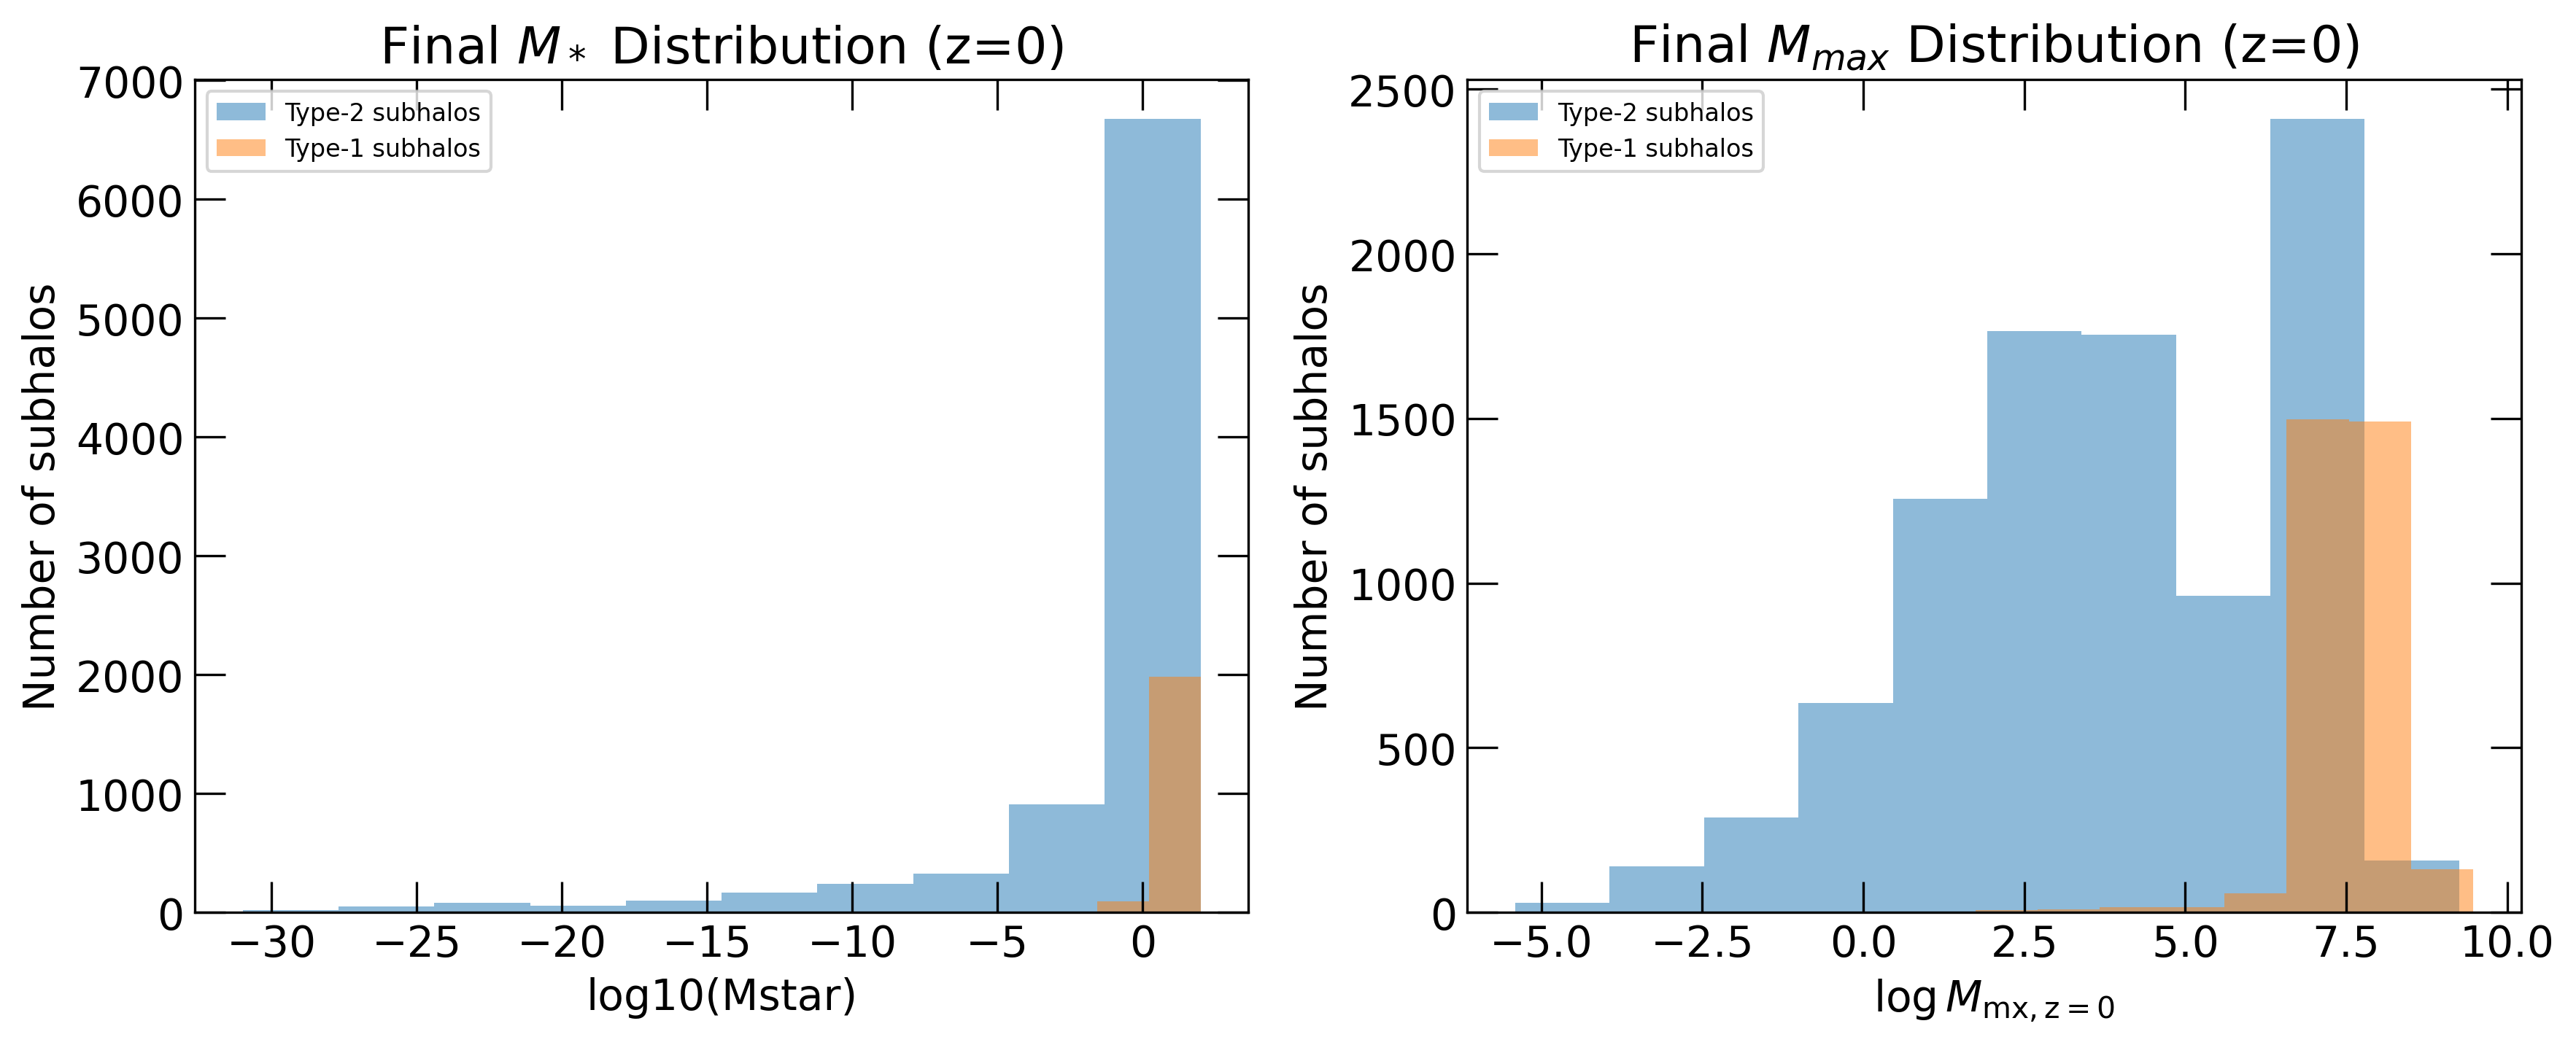

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Panel 1: Distribution of final Mstar
axs[0].hist(np.log10(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all<100) & (a4_t2_vpeak_ar > 12)]), alpha=0.5, label='Type-2 subhalos')
axs[0].hist(np.log10(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all<100) & (a4_t1_vpeak_ar > 12)]), alpha=0.5, label='Type-1 subhalos')
axs[0].set_xlabel('log10(Mstar)')
axs[0].set_ylabel('Number of subhalos')
axs[0].legend(fontsize=8)
axs[0].set_title('Final $M_*$ Distribution (z=0)')

# Panel 2: Distribution of final Mmax at z=0 for the same conditions
axs[1].hist(np.log10(a4_t2_mmx_f_ar[(a4_t2_mstar_pl_all<100) & (a4_t2_vpeak_ar > 12)]), alpha=0.5, label='Type-2 subhalos')
axs[1].hist(np.log10(a4_t1_mmx_f_ar[(a4_t1_mstar_pl_all<100) & (a4_t1_vpeak_ar > 12)]), alpha=0.5, label='Type-1 subhalos')
axs[1].set_xlabel(r'$\log M_{\rm{mx, z = 0}}$')
axs[1].set_ylabel('Number of subhalos')
axs[1].legend(fontsize=8)
axs[1].set_title('Final $M_{max}$ Distribution (z=0)')

plt.tight_layout()


14 14
14 14
14 14
14 14


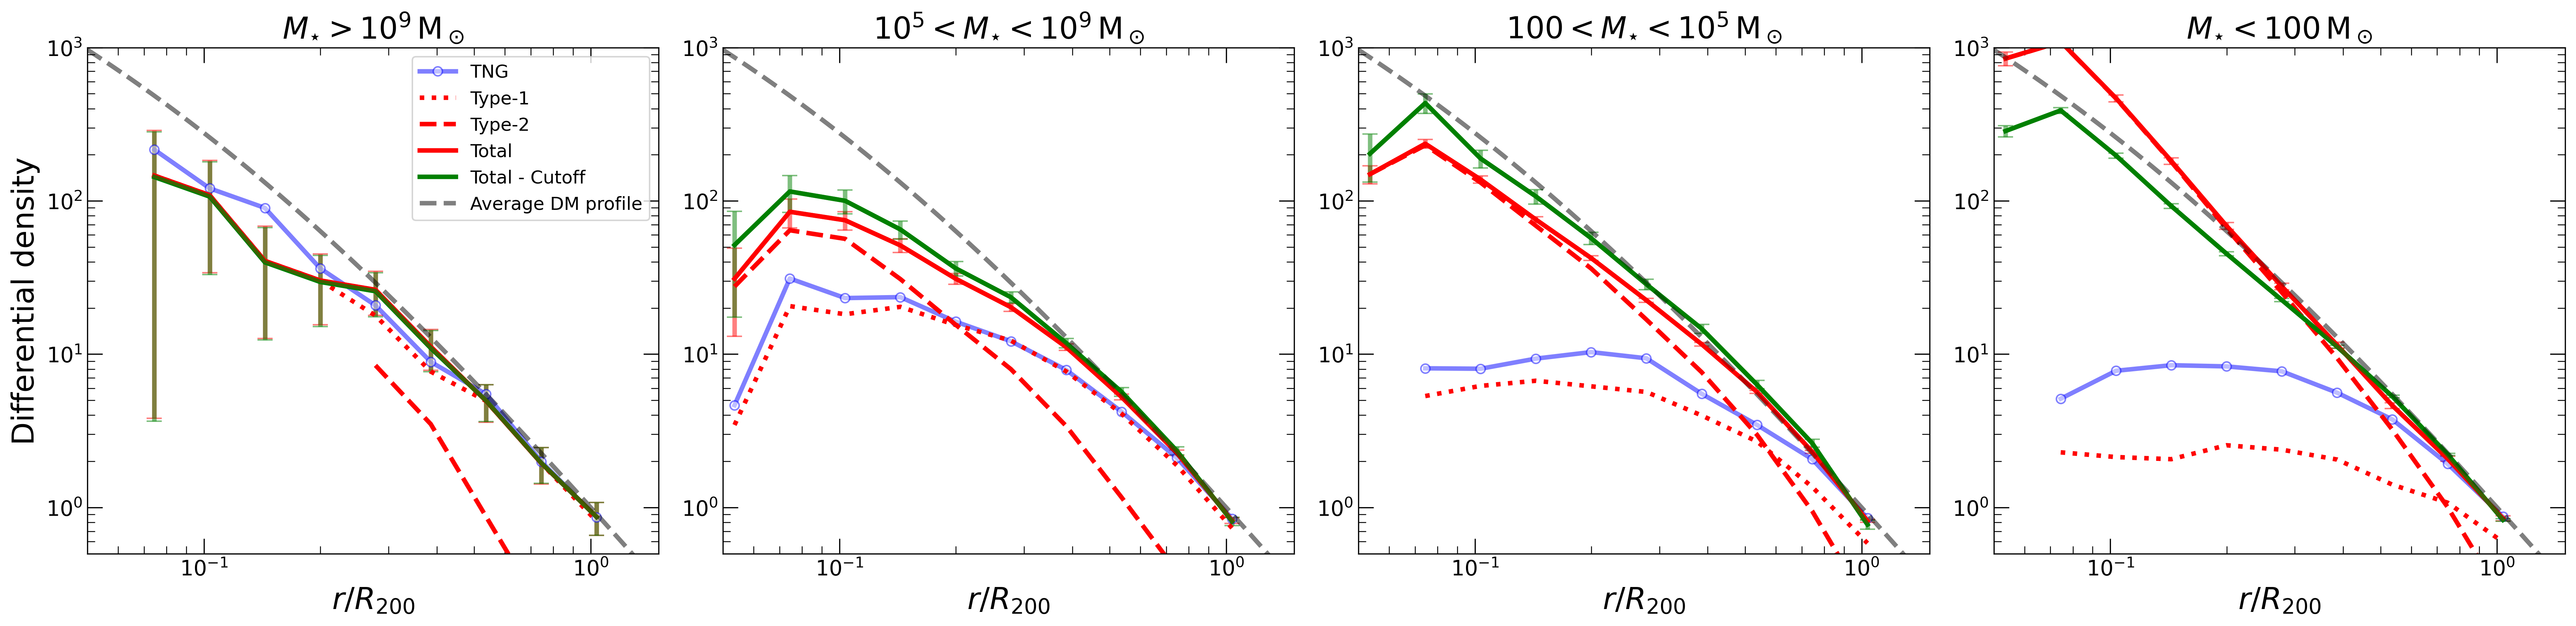

In [14]:
# a4_t1_rrel = a4_t1_dist_f_ar / r200_0
# a4_t2_rrel = a4_t2_dist_f_ar / r200_0
norm_rad = 1
a4_t1_rrel = np.zeros(len(a4_t1_fof))
a4_t2_rrel = np.zeros(len(a4_t2_fof))
a4_t1_rrel[a4_t1_fof == 0] = a4_t1_dist_f_ar[a4_t1_fof == 0] / r200_0
a4_t2_rrel[a4_t2_fof == 0] = a4_t2_dist_f_ar[a4_t2_fof == 0] / r200_0
a4_t1_rrel[a4_t1_fof == 1] = a4_t1_dist_f_ar[a4_t1_fof == 1] / r200_1
a4_t2_rrel[a4_t2_fof == 1] = a4_t2_dist_f_ar[a4_t2_fof == 1] / r200_1
a4_t1_rrel[a4_t1_fof == 2] = a4_t1_dist_f_ar[a4_t1_fof == 2] / r200_2
a4_t2_rrel[a4_t2_fof == 2] = a4_t2_dist_f_ar[a4_t2_fof == 2] / r200_2

fig, axs = plt.subplots(1, 4, figsize = (24, 6))

for jx in range(4): # This will be to loop over the three subplots that we have
    if jx == 0:
        mplcutoff = 10**9
        mmaxcutoff = 10**15
        axs[jx].set_title(r'$M_{\star} > 10^{9}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(-1.7, np.log10(2), 15) # We will be going till the virial radius of the FoF
    elif jx == 1:
        mplcutoff = 10**5
        mmaxcutoff = 10**9
        axs[jx].set_title(r'$10^{5} < M_{\star} < 10^{9}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(-1.7, np.log10(2), 15)
    elif jx ==2:
        mplcutoff = 100
        mmaxcutoff = 10**5
        axs[jx].set_title(r'$100 < M_{\star} < 10^{5}\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(-1.7, np.log10(2), 15)
    elif jx == 3:
        mplcutoff = -2
        mmaxcutoff = 100
        axs[jx].set_title(r'$M_{\star} < 100\,\rm{M_\odot}$', fontsize = label_font)
        rpl2 = np.logspace(-1.7, np.log10(2), 15)

    a4_t1_Nar = np.zeros(0) #shmf for surviving subhalos
    a4_t2_Nar = np.zeros(0) #shmf for merged subhalos

    a4_t1_co_Nar = np.zeros(0) #shmf for surviving subhalos from the cutoff
    a4_t2_co_Nar = np.zeros(0) #shmf for merged subhalos from the cutoff

    Ntng_ar = np.zeros(0)
    for (ix, rs) in enumerate(rpl2[1:]):
        a4_t1_Nar = np.append(a4_t1_Nar, len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > mplcutoff) & (a4_t1_mstar_pl_all < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))
        a4_t2_Nar = np.append(a4_t2_Nar, len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > mplcutoff) & (a4_t2_mstar_pl_all < mmaxcutoff) & (a4_t2_rrel < rs) & (a4_t2_rrel > rpl2[ix])]))

        a4_t1_co_Nar = np.append(a4_t1_co_Nar, len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > mplcutoff) & (a4_t1_mstar_co_all < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))
        a4_t2_co_Nar = np.append(a4_t2_co_Nar, len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > mplcutoff) & (a4_t2_mstar_co_all < mmaxcutoff) & (a4_t2_rrel < rs) & (a4_t2_rrel > rpl2[ix])]))
        Ntng_ar = np.append(Ntng_ar, len(a4_t1_mstar_f_ar_tng[(a4_t1_mstar_f_ar_tng > mplcutoff) & (a4_t1_mstar_f_ar_tng < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))
        # Ntng_ar = np.append(Ntng_ar, len(psmstar_f_ar_tng[(psmstar_f_ar_tng > mplcutoff) & (psmstar_f_ar_tng < mmaxcutoff)  & (psrrel < rs) & (psrrel > rpl2[ix - 1])]))


    Ntng_er = (np.sqrt(Ntng_ar)) / (rpl2[1:]**3 - rpl2[:-1]**3) / np.interp(norm_rad, rpl2[1:], Ntng_ar)
    a4_pl_er = (np.sqrt(a4_t1_Nar + a4_t2_Nar)) / (rpl2[1:]**3 - rpl2[:-1]**3) / np.interp(norm_rad, rpl2[1:], a4_t1_Nar + a4_t2_Nar)
    a4_co_er = (np.sqrt(a4_t1_co_Nar + a4_t2_co_Nar)) / (rpl2[1:]**3 - rpl2[:-1]**3) / np.interp(norm_rad, rpl2[1:], a4_t1_co_Nar + a4_t2_co_Nar)
    # print(a4_t1_Nar)
    # print(a4_t2_Nar)
    a4_tot_nar = (a4_t1_Nar + a4_t2_Nar) / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_nar = a4_t1_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_nar = a4_t1_nar / np.interp(1, rpl2[1:], a4_tot_nar)
    a4_t2_nar = a4_t2_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t2_nar = a4_t2_nar / np.interp(1, rpl2[1:], a4_tot_nar)

    a4_tot_nar = a4_tot_nar / np.interp(1, rpl2[1:], a4_tot_nar)

    a4_co_nar = (a4_t1_co_Nar + a4_t2_co_Nar) / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_co_nar = a4_t1_co_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_co_nar = a4_t1_co_nar / np.interp(1, rpl2[1:], a4_co_nar)
    a4_t2_co_nar = a4_t2_co_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t2_co_nar = a4_t2_co_nar / np.interp(1, rpl2[1:], a4_co_nar)

    a4_co_nar = a4_co_nar / np.interp(1, rpl2[1:], a4_co_nar)

    print(len(Ntng_ar), len(rpl2[1:]))

    Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)


    axs[jx].errorbar(rpl2[1:][a4_tot_nar != 0], a4_tot_nar[a4_tot_nar != 0], yerr = a4_pl_er[a4_tot_nar != 0], alpha = 0.5,
                        ms = 0, capsize = 5, color = 'red') # error bars for the power law
    axs[jx].errorbar(rpl2[1:][a4_co_nar != 0], a4_co_nar[a4_co_nar != 0], yerr = a4_co_er[a4_co_nar != 0], alpha = 0.5,
                        ms = 0, capsize = 5, color = 'green') # error bars for the cutoff model
    axs[jx].plot(rpl2[1:][Ntng_ar != 0], Ntng_ar[Ntng_ar != 0], 'bo-', label = r'TNG', alpha = 0.5, markerfacecolor = 'white')

    # Ntng_ar = Ntng_ar/Ntng_ar[-1] * ((rpl2[-1]**3 - rpl2[-2]**3)/ (rpl2[1:]**3 - rpl2[:-1]**3))

    axs[jx].plot(rpl2[1:][a4_t1_nar != 0], a4_t1_nar[a4_t1_nar != 0], 'r:', label = r'Type-1')
    axs[jx].plot(rpl2[1:][a4_t2_nar != 0], a4_t2_nar[a4_t2_nar != 0], 'r--', label = r'Type-2')
    axs[jx].plot(rpl2[1:][a4_tot_nar != 0], a4_tot_nar[a4_tot_nar != 0], 'r-', label = r'Total')
    # axs[jx].plot(rpl2[1:][a4_t1_co_nar != 0], a4_t1_co_nar[a4_t1_co_nar != 0], 'g:', label = r'Type-1 - Cutoff')
    # axs[jx].plot(rpl2[1:][a4_t2_co_nar != 0], a4_t2_co_nar[a4_t2_co_nar != 0], 'g--', label = r'Type-2 - Cutoff')
    axs[jx].plot(rpl2[1:][a4_co_nar != 0], a4_co_nar[a4_co_nar != 0], 'g-', label = r'Total - Cutoff')
    rdm_pl = np.logspace(-1.7, np.log10(2), 100)
    norm_rad = 1
    axs[jx].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) + 
                           nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                           nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.
                 ,  color = 'black', ls = '--', label = 'Average DM profile', alpha = 0.5, lw = 3)
    # axs[jx].plot(rdm_pl, nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2), color = 'black', ls = '--', label = 'DM in TNG', alpha = 0.5)
    if jx == 0:
        axs[jx].legend(fontsize = 12)
        axs[jx].set_ylabel(r'Differential density', fontsize = label_font)
    axs[jx].set_xlabel(r'$r / R_{200}$', fontsize = label_font)
    axs[jx].set_ylim(bottom = 0.5, top = 1e3)
    axs[jx].set_xlim(0.05, 1.5)
    axs[jx].set_xscale('log')
    axs[jx].set_yscale('log')
    axs[jx].minorticks_on()
    # axs[jx].axhline(1, color = 'black', ls = '--')
# plt.suptitle('FoF-0 No Mstar cut - Last bin until 0 Msun - Pot for inf before z = 3 is at z = 3', fontsize = 8)
plt.tight_layout()
plt.show()



    # axs[jx].plot(rpl2[1:][pN_ar != 0], pN_ar[pN_ar != 0], color = 'red', label = r'Power law', lw  = 3)




len of a4_t1_mstar_pl_all 24315
ken of a4_t1_rrel 24315
33910.0
Meadian number per bin for power law 466.0
255.02731155990884 0.0758577575029184 1.5
Best fit Einasto w/ alpha = 0.26for the mass range(2.0, 5.0)
383.1347114247648 0.0758577575029184 1.5
Best fit Einasto w/ alpha = 0.11for the mass max range(2.0, 5.0)
len of a4_t1_mstar_pl_all 24315
ken of a4_t1_rrel 24315
7997.0
Meadian number per bin for power law 52.0
28.45798326419584 0.0758577575029184 1.5
Best fit Einasto w/ alpha = 0.49for the mass range(5.0, 9.0)
120.59810217126666 0.0758577575029184 1.5
Best fit Einasto w/ alpha = 0.15for the mass max range(5.0, 9.0)
len of a4_t1_mstar_pl_all 24315
ken of a4_t1_rrel 24315
211.0
Meadian number per bin for power law 3.0
0.8012019543395844 0.08576958985908942 1.5
Best fit Einasto w/ alpha = 0.49for the mass range(9.0, 12.0)
2.179699770926452 0.08576958985908942 1.5
Best fit Einasto w/ alpha = 0.19for the mass max range(9.0, 12.0)
len of a4_t1_mstar_pl_all 24315
ken of a4_t1_rrel 2431

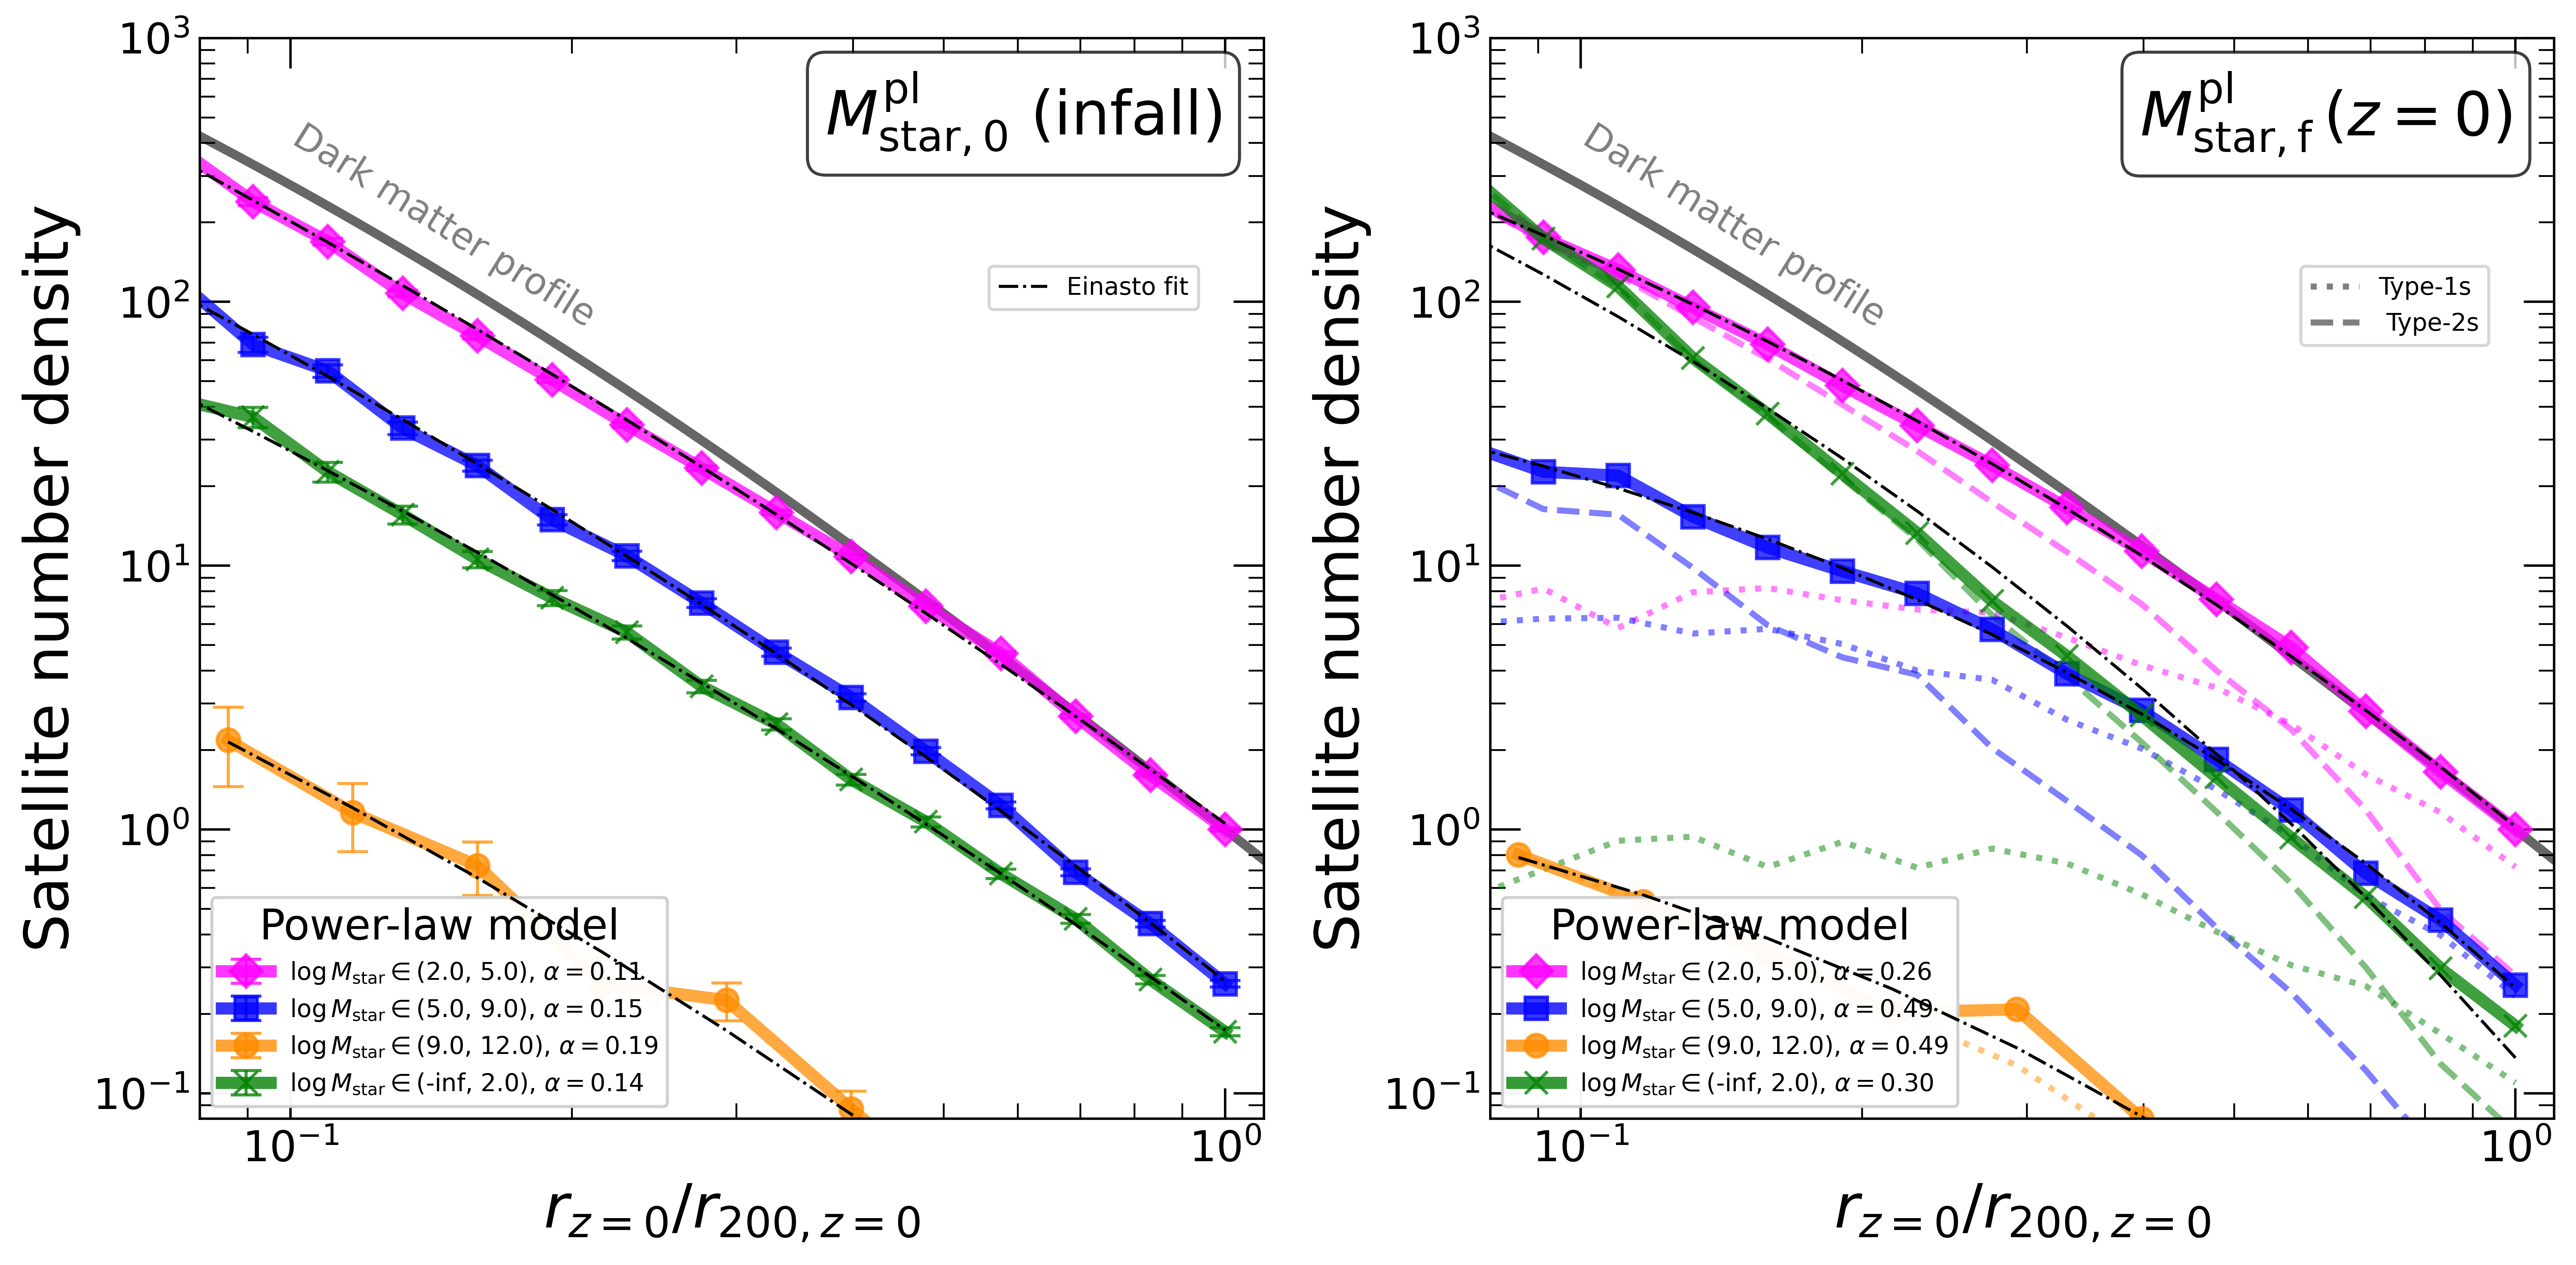

In [15]:
# This is to make the two panel plot for the radial distribution w/ diffrent normalization
fig, axs = plt.subplots(1, 2, figsize = (12, 6), dpi = 700)
# lss_ar = ['-', '--', ':']
col_ar = ['darkorange', 'blue', 'magenta', 'green']
marker_ar = ['o', 's', 'D', 'x']
norm_1 = 1
norm_2 = 1
for jx in [2, 1, 0, 3]: # This is to loop over the three mass ranges that we have for the stellar masses
    if jx == 0:
        mplcutoff = 10**9
        mmaxcutoff = 10**12
    elif jx == 1:
        mplcutoff = 10**5
        mmaxcutoff = 10**9
    elif jx ==2:
        mplcutoff = 100
        mmaxcutoff = 10**5
    elif jx ==3:
        mplcutoff = 0
        mmaxcutoff = 10**2

    if jx == 0: rpl2 = np.logspace(-1.2, np.log10(1), 10) # We will be going till twice the virial radius of the FoF
    if jx == 1 or jx ==2 or jx ==3 : rpl2 = np.logspace(-1.2, np.log10(1), 16) # We will be going till twice the virial radius of the FoF
    a4_t1_Nar_max = np.zeros(0) #shmf for surviving subhalos
    a4_t2_Nar_max = np.zeros(0) #shmf for merged subhalos

    a4_t1_co_Nar_max = np.zeros(0) #shmf for surviving subhalos from the cutoff
    a4_t2_co_Nar_max = np.zeros(0) #shmf for merged subhalos from the cutoff

    Ntng_ar_max = np.zeros(0)
    a4_t1_Nar = np.zeros(0) #shmf for surviving subhalos
    a4_t2_Nar = np.zeros(0) #shmf for merged subhalos

    a4_t1_co_Nar = np.zeros(0) #shmf for surviving subhalos from the cutoff
    a4_t2_co_Nar = np.zeros(0) #shmf for merged subhalos from the cutoff

    Ntng_ar = np.zeros(0)
    print('len of a4_t1_mstar_pl_all', len(a4_t1_mstar_pl_all))
    print('ken of a4_t1_rrel', len(a4_t1_rrel))
    for (ix, rs) in enumerate(rpl2[1:]):
        a4_t1_Nar = np.append(a4_t1_Nar, len(a4_t1_mstar_pl_all[(a4_t1_mstar_pl_all > mplcutoff) & (a4_t1_mstar_pl_all < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))
        a4_t2_Nar = np.append(a4_t2_Nar, len(a4_t2_mstar_pl_all[(a4_t2_mstar_pl_all > mplcutoff) & (a4_t2_mstar_pl_all < mmaxcutoff) & (a4_t2_rrel < rs) & (a4_t2_rrel > rpl2[ix])]))
        a4_t1_co_Nar = np.append(a4_t1_co_Nar, len(a4_t1_mstar_co_all[(a4_t1_mstar_co_all > mplcutoff) & (a4_t1_mstar_co_all < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))
        a4_t2_co_Nar = np.append(a4_t2_co_Nar, len(a4_t2_mstar_co_all[(a4_t2_mstar_co_all > mplcutoff) & (a4_t2_mstar_co_all < mmaxcutoff) & (a4_t2_rrel < rs) & (a4_t2_rrel > rpl2[ix])]))
        Ntng_ar = np.append(Ntng_ar, len(a4_t1_mstar_f_ar_tng[(a4_t1_mstar_f_ar_tng > mplcutoff) & (a4_t1_mstar_f_ar_tng < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))

        a4_t1_Nar_max = np.append(a4_t1_Nar_max, len(a4_t1_mstar_max_pl_all[(a4_t1_mstar_max_pl_all > mplcutoff) & (a4_t1_mstar_max_pl_all < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))
        a4_t2_Nar_max = np.append(a4_t2_Nar_max, len(a4_t2_mstar_max_pl_all[(a4_t2_mstar_max_pl_all > mplcutoff) & (a4_t2_mstar_max_pl_all < mmaxcutoff) & (a4_t2_rrel < rs) & (a4_t2_rrel > rpl2[ix])]))
        a4_t1_co_Nar_max = np.append(a4_t1_co_Nar_max, len(a4_t1_mstar_max_co_all[(a4_t1_mstar_max_co_all > mplcutoff) & (a4_t1_mstar_max_co_all < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))
        a4_t2_co_Nar_max = np.append(a4_t2_co_Nar_max, len(a4_t2_mstar_max_co_all[(a4_t2_mstar_max_co_all > mplcutoff) & (a4_t2_mstar_max_co_all < mmaxcutoff) & (a4_t2_rrel < rs) & (a4_t2_rrel > rpl2[ix])]))
        Ntng_ar_max = np.append(Ntng_ar_max, len(a4_t1_mstar_max_ar[(a4_t1_mstar_max_ar > mplcutoff) & (a4_t1_mstar_max_ar < mmaxcutoff) & (a4_t1_rrel < rs) & (a4_t1_rrel > rpl2[ix])]))

    print(np.sum(a4_t1_Nar) +  np.sum(a4_t2_Nar))
    print('Meadian number per bin for power law', np.min(a4_t1_Nar + a4_t2_Nar))
    
    # print(a4_t1_Nar)
    # print(a4_t2_Nar)
    

    a4_tot_nar = (a4_t1_Nar + a4_t2_Nar) / (rpl2[1:]**3 - rpl2[:-1]**3)

    if jx ==2 :
        norm_1 = np.interp(1, rpl2[1:], a4_tot_nar)

    Ntng_er = (np.sqrt(Ntng_ar)) / (rpl2[1:]**3 - rpl2[:-1]**3) / np.interp(norm_rad, rpl2[1:], Ntng_ar)
    a4_pl_er = (np.sqrt(a4_t1_Nar + a4_t2_Nar)) / (rpl2[1:]**3 - rpl2[:-1]**3) / norm_1
    a4_co_er = (np.sqrt(a4_t1_co_Nar + a4_t2_co_Nar)) / (rpl2[1:]**3 - rpl2[:-1]**3) / np.interp(norm_rad, rpl2[1:], a4_t1_co_Nar + a4_t2_co_Nar)

    a4_t1_nar = a4_t1_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_nar = a4_t1_nar / norm_1
    a4_t2_nar = a4_t2_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t2_nar = a4_t2_nar / norm_1

    a4_tot_nar = a4_tot_nar / norm_1

    a4_co_nar = (a4_t1_co_Nar + a4_t2_co_Nar) / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_co_nar = a4_t1_co_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_co_nar = a4_t1_co_nar / np.interp(1, rpl2[1:], a4_co_nar)
    a4_t2_co_nar = a4_t2_co_Nar / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t2_co_nar = a4_t2_co_nar / np.interp(1, rpl2[1:], a4_co_nar)

    a4_co_nar = a4_co_nar / np.interp(1, rpl2[1:], a4_co_nar)

    # print(len(Ntng_ar), len(rpl2[1:]))

    Ntng_ar = Ntng_ar/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar = Ntng_ar / np.interp(norm_rad, rpl2[1:], Ntng_ar)

    Ntng_ar_max = Ntng_ar_max/ (rpl2[1:]**3 - rpl2[:-1]**3)
    Ntng_ar_max = Ntng_ar_max / np.interp(norm_rad, rpl2[1:], Ntng_ar_max)
    
    a4_tot_max_nar = (a4_t1_Nar_max + a4_t2_Nar_max) / (rpl2[1:]**3 - rpl2[:-1]**3)
    if jx == 2:
        norm_2 = np.interp(1, rpl2[1:], a4_tot_max_nar)
    a4_pl_max_er = (np.sqrt(a4_t1_Nar_max + a4_t2_Nar_max)) / (rpl2[1:]**3 - rpl2[:-1]**3) / norm_2
    a4_co_max_er = (np.sqrt(a4_t1_co_Nar_max + a4_t2_co_Nar_max)) / (rpl2[1:]**3 - rpl2[:-1]**3) / norm_2
    a4_t1_max_nar = a4_t1_Nar_max / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_max_nar = a4_t1_max_nar / norm_2
    a4_t2_max_nar = a4_t2_Nar_max / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t2_max_nar = a4_t2_max_nar / norm_2

    a4_tot_max_nar = a4_tot_max_nar / norm_2

    a4_co_max_nar = (a4_t1_co_Nar_max + a4_t2_co_Nar_max) / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_co_max_nar = a4_t1_co_Nar_max / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t1_co_max_nar = a4_t1_co_max_nar / np.interp(1, rpl2[1:], a4_co_max_nar)
    a4_t2_co_max_nar = a4_t2_co_Nar_max / (rpl2[1:]**3 - rpl2[:-1]**3)
    a4_t2_co_max_nar = a4_t2_co_max_nar / np.interp(1, rpl2[1:], a4_co_max_nar)

    a4_co_max_nar = a4_co_max_nar / np.interp(1, rpl2[1:], a4_co_max_nar)

    lrho, lrs, alpha = fit_einasto(rpl2[1:][a4_tot_nar != 0], a4_tot_nar[a4_tot_nar != 0])[0]

    axs[1].errorbar(rpl2[1:][a4_tot_nar != 0], a4_tot_nar[a4_tot_nar != 0], yerr = a4_pl_er[a4_tot_nar != 0], alpha = 0.75, ms = 7.5, marker = marker_ar[jx], capsize = 0, color = col_ar[jx], lw = 4, elinewidth = 0, label = r'$\log M_{\rm star} \in$'+ f'({np.log10(mplcutoff)}, {np.log10(mmaxcutoff)}), ' + r'$\alpha = $' + f'{alpha:.2f}') # error bars for the power law
    # axs[1].errorbar(rpl2[1:][a4_co_nar != 0], a4_co_nar[a4_co_nar != 0], yerr = a4_co_er[a4_co_nar != 0], alpha = 0.5,
                        # ms = 0, capsize = 5, color = 'green', lw = 0, elinewidth = 0.5) # error bars for the cutoff model
    # axs[1].plot(rpl2[1:][Ntng_ar != 0], Ntng_ar[Ntng_ar != 0], 'bo-', label = r'TNG', alpha = 0.5, markerfacecolor = 'white')

    # Ntng_ar = Ntng_ar/Ntng_ar[-1] * ((rpl2[-1]**3 - rpl2[-2]**3)/ (rpl2[1:]**3 - rpl2[:-1]**3))

    axs[1].plot(rpl2[1:][a4_t1_nar != 0], a4_t1_nar[a4_t1_nar != 0], ':', color= col_ar[jx], lw = 2, alpha = 0.5)
    axs[1].plot(rpl2[1:][a4_t2_nar != 0], a4_t2_nar[a4_t2_nar != 0], '--', color = col_ar[jx], lw = 2, alpha = 0.5)
    # print(ls_ar[jx])
    # axs[1].plot(rpl2[1:][a4_tot_nar != 0], a4_tot_nar[a4_tot_nar != 0], color = col_ar[jx], label = r'$\log M_{\rm star} \in$'+ f'({np.log10(mplcutoff)}, {np.log10(mmaxcutoff)}), ' + r'$\alpha = $' + f'{alpha:.2f}', lw = 4)
    axs[1].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', lw = 1, zorder = 500)
    print('Best fit Einasto w/ alpha = ' + f'{alpha:.2f}'+ 'for the mass range' + f'({np.log10(mplcutoff)}, {np.log10(mmaxcutoff)})')
    # axs[1].plot(rpl2[1:][a4_t1_co_nar != 0], a4_t1_co_nar[a4_t1_co_nar != 0], 'g:', label = r'Type-1 - Cutoff')
    # axs[1].plot(rpl2[1:][a4_t2_co_nar != 0], a4_t2_co_nar[a4_t2_co_nar != 0], 'g--', label = r'Type-2 - Cutoff')
    # axs[1].plot(rpl2[1:][a4_co_nar != 0], a4_co_nar[a4_co_nar != 0], 'g', ls = lss_ar[jx], label = r'Total - Cutoff')
    lrho, lrs, alpha = fit_einasto(rpl2[1:][a4_tot_max_nar != 0], a4_tot_max_nar[a4_tot_max_nar != 0])[0]
    axs[0].errorbar(rpl2[1:][a4_tot_max_nar != 0], a4_tot_max_nar[a4_tot_max_nar != 0], yerr = a4_pl_max_er[a4_tot_max_nar != 0], alpha = 0.75, marker = marker_ar[jx],
                        markersize = 7.5, capsize = 5, color = col_ar[jx], lw = 4, elinewidth = 1, label = r'$\log M_{\rm star} \in$'+ f'({np.log10(mplcutoff)}, {np.log10(mmaxcutoff)}), ' + r'$\alpha = $' + f'{alpha:.2f}') # error bars for the power law
    # axs[0].errorbar(rpl2[1:][a4_co_max_nar != 0], a4_co_max_nar[a4_co_max_nar != 0], yerr = a4_co_max_er[a4_co_max_nar != 0], alpha = 0.5,
                        # ms = 0, capsize = 5, color = 'green', lw = 0, elinewidth = 0.5) # error bars for the cutoff model
    # axs[0].plot(rpl2[1:][Ntng_ar_max != 0], Ntng_ar_max[Ntng_ar_max != 0], 'bo-', label = r'TNG', alpha = 0.5, markerfacecolor = 'white')

    # Ntng_ar = Ntng_ar/Ntng_ar[-1] * ((rpl2[-1]**3 - rpl2[-2]**3)/ (rpl2[1:]**3 - rpl2[:-1]**3))

    # axs[0].plot(rpl2[1:][a4_t1_max_nar != 0], a4_t1_max_nar[a4_t1_max_nar != 0], 'r:', label = r'Type-1')
    # axs[0].plot(rpl2[1:][a4_t2_max_nar != 0], a4_t2_max_nar[a4_t2_max_nar != 0], 'r--', label = r'Type-2')
    # print(ls_ar[jx])
    
    # axs[0].plot(rpl2[1:][a4_tot_max_nar != 0], a4_tot_max_nar[a4_tot_max_nar != 0], color = col_ar[jx], label =  r'$\log M_{\rm star} \in$'+ f'({np.log10(mplcutoff)}, {np.log10(mmaxcutoff)}), ' + r'$\alpha = $' + f'{alpha:.2f}', lw = 4)
    axs[0].plot(rpl2[1:], 10**einasto_density(np.log10(rpl2[1:]), lrho, lrs, alpha), color = 'black', ls = '-.', lw = 1, zorder = 500)
    print('Best fit Einasto w/ alpha = ' + f'{alpha:.2f}'+ 'for the mass max range' + f'({np.log10(mplcutoff)}, {np.log10(mmaxcutoff)})')
    # axs[0].plot(rpl2[1:][a4_t1_co_max_nar != 0], a4_t1_co_max_nar[a4_t1_co_max_nar != 0], 'g:', label = r'Type-1 - Cutoff')
    # axs[0].plot(rpl2[1:][a4_t2_co_max_nar != 0], a4_t2_co_max_nar[a4_t2_co_max_nar != 0], 'g--', label = r'Type-2 - Cutoff')
    # axs[0].plot(rpl2[1:][a4_co_max_nar != 0], a4_co_max_nar[a4_co_max_nar != 0], 'g', ls = lss_ar[jx], label = r'Total - Cutoff')

rdm_pl = np.logspace(-1.7, np.log10(2), 100)
norm_rad = 1
axs[0].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) + 
                           nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                           nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.
                 ,  color = 'black', ls = '-', lw = 3, alpha = 0.6)
axs[1].plot(rdm_pl , (nfw_dens(rdm_pl * r200_0, rhos_0, rs_0) / nfw_dens(norm_rad * r200_0, rhos_0, rs_0) + 
                           nfw_dens(rdm_pl * r200_1, rhos_1, rs_1) / nfw_dens(norm_rad * r200_1, rhos_1, rs_1) + 
                           nfw_dens(rdm_pl * r200_2, rhos_2, rs_2) / nfw_dens(norm_rad * r200_2, rhos_2, rs_2)) / 3.
                 ,  color = 'black', ls = '-', lw = 3, alpha = 0.6)

first_legend = axs[0].legend(fontsize = 8, loc = 'lower left', title = 'Power-law model')
axs[0].add_artist(first_legend)

from matplotlib.legend import Legend
    
legend_elements = [
    plt.Line2D([0], [0], color='black', lw=1, label='Best-fit Einasto', ls = '-.'),
]

leg = Legend(axs[0], legend_elements, ['Einasto fit'], fontsize = 8, bbox_to_anchor=(0.95, 0.8))
axs[0].add_artist(leg)

axs[0].text(0.96, 0.97, r'$M_{\rm star, 0}^{\rm pl}$ (infall)', fontsize = label_font, color = 'black', transform = axs[0].transAxes, ha = 'right', va = 'top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white', alpha=0.75))
axs[0].annotate(r'Dark matter profile', xy = (0.1, 400), xytext = (0.1, 400), 
    rotation=-32, color='gray', fontsize=12, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))
axs[0].set_ylabel(r'Satellite number density', fontsize = label_font)
axs[0].set_xlabel(r'$r_{z= 0} / r_{200, z = 0}$', fontsize = label_font)
axs[0].set_ylim(bottom = 0.08, top = 1e3)
axs[0].set_xlim(0.08, 1.1)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].minorticks_on()


legend = axs[1].legend(fontsize = 8, loc = 'lower left', title = 'Power-law model')
axs[1].add_artist(legend)

legend_elements = [
    plt.Line2D([0], [0], color='black', lw=2, alpha = 0.5, label='Type1s', ls = ':'),
    plt.Line2D([0], [0], color='black', lw=2, alpha = 0.5, label='Type2s', ls = '--'),
]

leg = Legend(axs[1], legend_elements, ['Type-1s', ' Type-2s'], fontsize = 8, bbox_to_anchor=(0.95, 0.8))
axs[1].add_artist(leg)


axs[1].set_ylabel(r'Satellite number density', fontsize = label_font)
axs[1].text(0.96, 0.97, r'$M_{\rm star, f}^{\rm pl} \,(z = 0)$', fontsize = label_font, color = 'black', transform = axs[1].transAxes, ha = 'right', va = 'top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='black', facecolor='white', alpha=0.75))
axs[1].annotate(r'Dark matter profile', xy = (0.1, 400), xytext = (0.1, 400), 
    rotation=-32, color='gray', fontsize=12, rotation_mode='anchor',
            bbox=dict(boxstyle='round,pad=0.1', edgecolor='none', facecolor='white', alpha=0.75))

axs[1].set_xlabel(r'$r_{z = 0} / r_{200, z = 0}$', fontsize = label_font)
axs[1].set_ylim(bottom = 0.08, top = 1e3)
axs[1].set_xlim(0.08, 1.1)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].minorticks_on()

plt.tight_layout()
plt.show()

75.60134550731922